# Experiment: Shuli Cross-Method Oracle MCMC-IS

Objective:
- Re-run two Shuli original scenarios with exact p-values near `1e-7` and `1e-9`.
- Compare `iid`, `samc`, and `oracle_mcmcis` using a common `5,000,000` evaluation budget per run.
- Use 10 independent repeats per method and parallel worker execution when available.
- For MCMC-IS, use only oracle p-value initialization: `p0 = exact_p`, `q_target = p0 ** (1/3)`, no local scan and no HPO.


In [1]:
from __future__ import annotations

from dataclasses import asdict
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "perm_pval").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing perm_pval/ and notebooks/.")


project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.environ.setdefault("MPLCONFIGDIR", str(project_root / ".matplotlib"))

from perm_pval.experiments.notebook_studies import (
    CrossMethodStudyConfig,
    MCMCWorkflowConfig,
    SAMCWorkflowConfig,
    _effective_n_jobs,
    _iid_replicate_worker,
    _samc_replicate_worker,
    _try_make_process_pool,
    build_beta_initialization,
    create_timestamped_run_dir,
    load_cross_method_saved_output,
    plot_named_method_convergence,
    plot_named_method_max_budget,
    run_named_mcmc_checkpoint_study,
    summarize_records,
    tune_samc_setup,
    write_json,
    write_jsonl,
)
from perm_pval.experiments.exact_scenarios import load_saved_exact_scenarios
from perm_pval.experiments.shuli_scenarios import build_shuli_scenarios

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
project_root


PosixPath('/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS')

## Configuration

This notebook intentionally avoids the oracle-beta-search/HPO machinery. MCMC-IS beta is initialized once per scenario from the true exact p-value and an IID pilot used only to estimate the statistic scale. The production chain budget remains `5M` per run; the MCMC pilot is reported separately in metadata.


In [2]:
FAST_MODE = False
SAVE_OUTPUTS = True

SCENARIO_KEYS = [
    "shuli_abs_sumdiff_exm3",  # exact p ≈ 4.14e-7
    "shuli_abs_sumdiff_exm2",  # exact p ≈ 7.36e-9
]

BASE_SEED = 72_019
N_METHOD_RUNS = 10 if not FAST_MODE else 2
N_JOBS = min(10, os.cpu_count() or 1)
CHAIN_BUDGET = 5_000_000 if not FAST_MODE else 100_000
CHECKPOINT_STEP = 250_000 if not FAST_MODE else 25_000
ESTIMATION_POINTS = tuple(range(CHECKPOINT_STEP, CHAIN_BUDGET + CHECKPOINT_STEP, CHECKPOINT_STEP))
SHULI_SWAP_PAIRS = 5

SHULI_CATALOG_PATH = project_root / "results" / "exact_scenarios" / "shuli_scenarios" / "catalog.json"
OUTPUT_ROOT = project_root / "results" / "cross_method_shuli_notebook"

METHOD_ORDER = ["iid", "samc", "oracle_mcmcis"]
METHOD_LABELS = {
    "iid": "IID",
    "samc": "SAMC",
    "oracle_mcmcis": "Oracle-init MCMC-IS",
}
METHOD_COLORS = {
    "iid": "#5b6c8f",
    "samc": "#4c8c77",
    "oracle_mcmcis": "#b04a5a",
}

cross_cfg = CrossMethodStudyConfig(
    estimation_points=ESTIMATION_POINTS,
    repeats=N_METHOD_RUNS,
    base_seed=BASE_SEED,
    iid_density_samples=120_000 if not FAST_MODE else 5_000,
    min_tail_states=1,
    n_jobs=N_JOBS,
)

oracle_init_cfg = MCMCWorkflowConfig(
    use_true_p0_for_q_target=True,
    d_alpha=1.0 / 3.0,
    pilot_samples=200_000 if not FAST_MODE else 5_000,
    scale_method="sd",
    beta_max_init=1e6,
    tune_steps=0,
    chains=1,
    burn_in_fraction=0.20,
    thin=1,
    estimate_variance=True,
    obm_batch_size=None,
    chain_n_jobs=1,
    tilt_mode="smooth_hinge",
    proposal_size=SHULI_SWAP_PAIRS,
    local_scan_enabled=False,
)

mcmc_template_cfg = MCMCWorkflowConfig(
    pilot_samples=0,
    tune_steps=0,
    chains=1,
    burn_in_fraction=0.20,
    thin=1,
    estimate_variance=True,
    obm_batch_size=None,
    chain_n_jobs=1,
    tilt_mode="smooth_hinge",
    proposal_size=SHULI_SWAP_PAIRS,
    local_scan_enabled=False,
)

samc_base_cfg = SAMCWorkflowConfig(
    burn_in_fraction=0.20,
    n_bins=101,
    t0=10_000.0,
    trace_every=2_000 if not FAST_MODE else 200,
    convergence_tolerance=20.0,
    lambda_min_pilot=20_000 if not FAST_MODE else 2_000,
    proposal_size=SHULI_SWAP_PAIRS,
)

NOTEBOOK_CONFIG = {
    "FAST_MODE": bool(FAST_MODE),
    "SAVE_OUTPUTS": bool(SAVE_OUTPUTS),
    "SCENARIO_KEYS": list(SCENARIO_KEYS),
    "SHULI_CATALOG_PATH": str(SHULI_CATALOG_PATH),
    "BASE_SEED": int(BASE_SEED),
    "N_METHOD_RUNS": int(N_METHOD_RUNS),
    "N_JOBS": int(N_JOBS),
    "CHAIN_BUDGET": int(CHAIN_BUDGET),
    "CHECKPOINT_STEP": int(CHECKPOINT_STEP),
    "N_CHECKPOINTS": int(len(ESTIMATION_POINTS)),
    "SHULI_SWAP_PAIRS": int(SHULI_SWAP_PAIRS),
    "MCMC_ORACLE_INIT_D_ALPHA": float(oracle_init_cfg.d_alpha),
    "MCMC_ORACLE_INIT_PILOT_SAMPLES": int(oracle_init_cfg.pilot_samples),
    "MCMC_COUNTS_INCLUDE_INIT_PILOT": False,
    "SAMC_N_BINS": int(samc_base_cfg.n_bins),
    "SAMC_T0": float(samc_base_cfg.t0),
    "METHOD_ORDER": list(METHOD_ORDER),
}

print(json.dumps(NOTEBOOK_CONFIG, indent=2))


{
  "FAST_MODE": false,
  "SAVE_OUTPUTS": true,
  "SCENARIO_KEYS": [
    "shuli_abs_sumdiff_exm3",
    "shuli_abs_sumdiff_exm2"
  ],
  "SHULI_CATALOG_PATH": "/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/exact_scenarios/shuli_scenarios/catalog.json",
  "BASE_SEED": 72019,
  "N_METHOD_RUNS": 10,
  "N_JOBS": 8,
  "CHAIN_BUDGET": 5000000,
  "CHECKPOINT_STEP": 250000,
  "N_CHECKPOINTS": 20,
  "SHULI_SWAP_PAIRS": 5,
  "MCMC_ORACLE_INIT_D_ALPHA": 0.3333333333333333,
  "MCMC_ORACLE_INIT_PILOT_SAMPLES": 200000,
  "MCMC_COUNTS_INCLUDE_INIT_PILOT": false,
  "SAMC_N_BINS": 101,
  "SAMC_T0": 10000.0,
  "METHOD_ORDER": [
    "iid",
    "samc",
    "oracle_mcmcis"
  ]
}


## Helpers

These mirror the existing cross-method notebook, but remove the simple/HPO MCMC-IS branches. Each method gets independent repeat seeds and the same production checkpoints.


In [3]:
def exact_p_of(scenario) -> float:
    return float(scenario.exact_p_value)


def scenario_description(scenario) -> str:
    return str(scenario.description)


def run_parallel_worker_jobs(worker_fn, jobs: list[dict], *, n_jobs: int) -> list[dict]:
    n_workers = _effective_n_jobs(int(n_jobs), len(jobs))
    executor = _try_make_process_pool(n_workers) if n_workers > 1 else None
    rows: list[dict] = []
    if executor is None:
        for job in jobs:
            rows.extend(worker_fn(**job))
        return rows

    with executor:
        futures = [executor.submit(worker_fn, **job) for job in jobs]
        for future in futures:
            rows.extend(future.result())
    return rows


def build_oracle_mcmcis_reference(scenario, *, seed: int) -> dict:
    init_payload = build_beta_initialization(
        scenario.problem,
        exact_p_of(scenario),
        oracle_init_cfg,
        seed=int(seed),
    )
    return {
        "scenario": scenario.key,
        "reference_p0": float(exact_p_of(scenario)),
        "gamma": float(oracle_init_cfg.d_alpha),
        "q_target": float(init_payload["q_target"]),
        "beta": float(init_payload["beta0_laplace"]),
        "beta0_formula": float(init_payload["beta0_formula"]),
        "sigma_t": float(init_payload["sigma_t"]),
        "proposal_size": int(SHULI_SWAP_PAIRS),
        "pilot_eval_total": int(init_payload["pilot_eval_total"]),
        "pilot_wall_time_sec": float(init_payload["pilot_wall_time_sec"]),
    }


def run_iid_baseline(scenario, *, base_seed: int) -> list[dict]:
    checkpoints = tuple(int(v) for v in cross_cfg.estimation_points)
    jobs = [
        {
            "scenario_key": scenario.key,
            "scenario_display": scenario_description(scenario),
            "problem": scenario.problem,
            "exact_p": exact_p_of(scenario),
            "checkpoints": checkpoints,
            "rep": int(rep),
            "rep_seed": int(base_seed + 1_000 * rep),
            "confidence_level": float(cross_cfg.confidence_level),
        }
        for rep in range(int(cross_cfg.repeats))
    ]
    rows = run_parallel_worker_jobs(_iid_replicate_worker, jobs, n_jobs=int(cross_cfg.n_jobs))
    for row in rows:
        row["label"] = "iid"
    return rows


def run_oracle_mcmcis_baseline(scenario, oracle_reference: dict, *, base_seed: int) -> dict:
    return run_named_mcmc_checkpoint_study(
        scenario.problem,
        exact_p_of(scenario),
        config_specs=[
            {
                "label": "oracle_mcmcis",
                "config_id": "oracle_p_init_gamma_1over3",
                "beta": float(oracle_reference["beta"]),
                "proposal_size": int(oracle_reference["proposal_size"]),
                "source": "oracle_pvalue_initialization",
            }
        ],
        sigma_t=float(oracle_reference["sigma_t"]),
        estimation_points=tuple(int(v) for v in cross_cfg.estimation_points),
        repeats=int(cross_cfg.repeats),
        base_seed=int(base_seed),
        template_cfg=mcmc_template_cfg,
        n_jobs=int(cross_cfg.n_jobs),
    )


def run_samc_baseline(scenario, *, base_seed: int, samc_cfg: SAMCWorkflowConfig) -> tuple[list[dict], dict]:
    checkpoints = tuple(int(v) for v in cross_cfg.estimation_points)
    samc_setup = tune_samc_setup(
        scenario.problem,
        samc_cfg,
        seed=int(base_seed + 50_000),
    )
    jobs = [
        {
            "scenario_key": scenario.key,
            "scenario_display": scenario_description(scenario),
            "problem": scenario.problem,
            "exact_p": exact_p_of(scenario),
            "checkpoints": checkpoints,
            "samc_setup": samc_setup,
            "samc_cfg": samc_cfg,
            "rep": int(rep),
            "rep_seed": int(base_seed + 100_000 + 1_000 * rep),
        }
        for rep in range(int(cross_cfg.repeats))
    ]
    rows = run_parallel_worker_jobs(_samc_replicate_worker, jobs, n_jobs=int(cross_cfg.n_jobs))
    for row in rows:
        row["label"] = "samc"
    return rows, samc_setup


def samc_correction_summary(records: list[dict]) -> pd.DataFrame:
    rows = [row for row in records if row.get("label") == "samc"]
    if not rows:
        return pd.DataFrame()
    return (
        pd.DataFrame(rows)
        .groupby("checkpoint", as_index=False)
        .agg(
            mean_samc_estimate=("estimate", "mean"),
            mean_no_empty_bin_correction=("samc_estimate_no_empty_bin_correction", "mean"),
            mean_empty_bin_delta=("samc_empty_bin_correction_delta", "mean"),
            median_empty_bin_ratio=("samc_empty_bin_correction_ratio", "median"),
            mean_empty_bins=("samc_empty_bins", "mean"),
            mean_pi0=("samc_pi0", "mean"),
        )
    )


def save_shuli_cross_method_outputs(scenario, study: dict, *, output_dir: Path, samc_cfg: SAMCWorkflowConfig) -> None:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    max_budget = max(int(v) for v in study["estimation_points"])

    plot_named_method_max_budget(
        study["records"],
        scenario_name=study["scenario_display"],
        scenario_key=study["scenario"],
        exact_p=float(study["exact_p"]),
        max_budget=max_budget,
        method_order=METHOD_ORDER,
        method_labels=METHOD_LABELS,
        method_colors=METHOD_COLORS,
        n_control=int(scenario.problem.n_control),
        n_treated=int(scenario.problem.n_treated),
        save_path=output_dir / "cross_method_max_budget.png",
    )
    plot_named_method_convergence(
        study["summary"],
        scenario_name=study["scenario_display"],
        scenario_key=study["scenario"],
        exact_p=float(study["exact_p"]),
        method_order=METHOD_ORDER,
        method_labels=METHOD_LABELS,
        method_colors=METHOD_COLORS,
        n_control=int(scenario.problem.n_control),
        n_treated=int(scenario.problem.n_treated),
        x_label="Budget per run",
        save_path=output_dir / "cross_method_convergence_mean.png",
    )
    plot_named_method_convergence(
        study["summary"],
        scenario_name=study["scenario_display"],
        scenario_key=study["scenario"],
        exact_p=float(study["exact_p"]),
        method_order=METHOD_ORDER,
        method_labels=METHOD_LABELS,
        method_colors=METHOD_COLORS,
        n_control=int(scenario.problem.n_control),
        n_treated=int(scenario.problem.n_treated),
        x_label="Budget per run",
        estimate_field="median_estimate",
        estimate_title="Median estimate",
        estimate_ylabel=r"median $\hat{p}$",
        save_path=output_dir / "cross_method_convergence_median.png",
    )

    write_jsonl(output_dir / "run_records.jsonl", study["records"])
    write_json(output_dir / "summary.json", study["summary"])
    write_json(
        output_dir / "metadata.json",
        {
            "scenario": study["scenario"],
            "scenario_display": study["scenario_display"],
            "scenario_portfolio": study["scenario_portfolio"],
            "exact_p": float(study["exact_p"]),
            "exact_method": study["exact_method"],
            "exact_tail_hits": int(study["exact_tail_hits"]),
            "exact_n_perm": int(study["exact_n_perm"]),
            "n_treated": int(scenario.problem.n_treated),
            "n_control": int(scenario.problem.n_control),
            "n_total": int(scenario.problem.n),
            "estimation_points": study["estimation_points"],
            "method_order": list(METHOD_ORDER),
            "method_labels": dict(METHOD_LABELS),
            "method_colors": dict(METHOD_COLORS),
            "cross_config": asdict(cross_cfg),
            "oracle_init_config": asdict(oracle_init_cfg),
            "mcmc_template_config": asdict(mcmc_template_cfg),
            "samc_config": asdict(samc_cfg),
            "oracle_reference": study["oracle_reference"],
            "samc_setup": study["samc_setup"],
            "notebook_config": NOTEBOOK_CONFIG,
        },
    )


## Load Shuli Scenarios

We load the saved Shuli scenario catalog when available, then select one scenario around `4e-7` and one around `7e-9`. The fifth data pair exists in the file but is not part of this run.


In [4]:
if SHULI_CATALOG_PATH.exists():
    shuli_catalog = load_saved_exact_scenarios(SHULI_CATALOG_PATH)
    shuli_catalog_source = str(SHULI_CATALOG_PATH)
else:
    shuli_catalog = build_shuli_scenarios()
    shuli_catalog_source = "embedded build_shuli_scenarios() fallback"

all_shuli_scenarios = {scenario.key: scenario for scenario in shuli_catalog}
scenarios = [all_shuli_scenarios[key] for key in SCENARIO_KEYS]
run_dir = None
print("Shuli catalog source:", shuli_catalog_source)

pd.DataFrame(
    [
        {
            "scenario": scenario.key,
            "exact_p": exact_p_of(scenario),
            "tail_hits": int(scenario.tail_hits),
            "n_perm": int(scenario.n_permutations),
            "lambda_star": int(scenario.extra["lambda_star"]),
            "sum_x1": int(scenario.extra["sum_x1"]),
            "sum_x2": int(scenario.extra["sum_x2"]),
            "row_pair": tuple(scenario.extra["row_pair"]),
            "rarity_band": scenario.portfolio.get("rarity_band"),
        }
        for scenario in scenarios
    ]
)


Shuli catalog source: /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/exact_scenarios/shuli_scenarios/catalog.json


,scenario,exact_p,tail_hits,n_perm,lambda_star,sum_x1,sum_x2,row_pair,rarity_band
0,shuli_abs_sumdiff_exm3,4.138940e-07,3747749061371285045834094990837341254739506391...,9054851465610328116540417707748416387450458967...,138,216,354,"(6, 7)",extreme
1,shuli_abs_sumdiff_exm2,7.360743e-09,6665043736831862973943490584614865766920486517...,9054851465610328116540417707748416387450458967...,129,175,304,"(4, 5)",ultra_rare


## Run Cross-Method Study

This is the expensive cell. With `FAST_MODE=False`, it runs `2 scenarios × 3 methods × 10 repeats × 5M` production evaluations, with worker parallelism controlled by `N_JOBS`.


In [5]:
cross_results: dict[str, dict] = {}
if SAVE_OUTPUTS and run_dir is None:
    run_dir = create_timestamped_run_dir(OUTPUT_ROOT, "shuli_cross_method_oracle_init")

for scenario_idx, scenario in enumerate(scenarios):
    scenario_seed = int(BASE_SEED + 1_000_000 * (scenario_idx + 1))
    print(f"Running {scenario.key} | exact p={exact_p_of(scenario):.3e}")

    oracle_reference = build_oracle_mcmcis_reference(
        scenario,
        seed=int(scenario_seed + 10_000),
    )
    scenario_samc_cfg = samc_base_cfg

    print(json.dumps({
        "scenario": scenario.key,
        "n_method_runs": int(cross_cfg.repeats),
        "n_jobs": int(cross_cfg.n_jobs),
        "chain_budget": int(CHAIN_BUDGET),
        "proposal_size": int(SHULI_SWAP_PAIRS),
        "oracle_reference_p0": oracle_reference["reference_p0"],
        "oracle_gamma": oracle_reference["gamma"],
        "oracle_q_target": oracle_reference["q_target"],
        "oracle_beta": oracle_reference["beta"],
        "oracle_sigma_t": oracle_reference["sigma_t"],
        "mcmc_pilot_eval_total": oracle_reference["pilot_eval_total"],
        "samc_n_bins": int(scenario_samc_cfg.n_bins),
        "samc_t0": float(scenario_samc_cfg.t0),
    }, indent=2))

    iid_rows = run_iid_baseline(
        scenario,
        base_seed=int(scenario_seed + 100_000),
    )
    mcmc_study = run_oracle_mcmcis_baseline(
        scenario,
        oracle_reference,
        base_seed=int(scenario_seed + 200_000),
    )
    samc_rows, samc_setup = run_samc_baseline(
        scenario,
        base_seed=int(scenario_seed + 300_000),
        samc_cfg=scenario_samc_cfg,
    )

    records = list(iid_rows) + list(mcmc_study["records"]) + list(samc_rows)
    records = sorted(
        records,
        key=lambda row: (
            str(row.get("label", row.get("method", ""))),
            int(row["replicate"]),
            int(row["checkpoint"]),
        ),
    )
    summary = summarize_records(records, group_fields=("checkpoint", "label"))

    study = {
        "scenario": scenario.key,
        "scenario_display": scenario_description(scenario),
        "scenario_portfolio": dict(scenario.portfolio),
        "exact_p": exact_p_of(scenario),
        "exact_method": scenario.exact_method,
        "exact_tail_hits": int(scenario.tail_hits),
        "exact_n_perm": int(scenario.n_permutations),
        "estimation_points": [int(v) for v in cross_cfg.estimation_points],
        "records": records,
        "summary": summary,
        "oracle_reference": oracle_reference,
        "samc_setup": {
            "lambda_min": float(samc_setup["lambda_min"]),
            "bin_edges": np.asarray(samc_setup["bin_edges"], dtype=float),
        },
    }
    cross_results[scenario.key] = study

    if SAVE_OUTPUTS and run_dir is not None:
        save_shuli_cross_method_outputs(
            scenario,
            study,
            output_dir=run_dir / scenario.key,
            samc_cfg=scenario_samc_cfg,
        )

    summary_df = pd.DataFrame(summary).sort_values(["checkpoint", "label"])
    display(
        summary_df[
            [
                "checkpoint",
                "label",
                "mean_estimate",
                "median_estimate",
                "rmse",
                "mean_abs_log10_error",
                "mean_q_tilt_tail_share",
                "mean_ess",
                "mean_acceptance_rate",
                "mean_zero_rate",
                "mean_samc_max_rel_freq_error",
            ]
        ].tail(3 * len(METHOD_ORDER))
    )

    correction_df = samc_correction_summary(records)
    if not correction_df.empty:
        display(correction_df.tail(5))

print("Output directory:", run_dir)


Running shuli_abs_sumdiff_exm3 | exact p=4.139e-07
{
  "scenario": "shuli_abs_sumdiff_exm3",
  "n_method_runs": 10,
  "n_jobs": 8,
  "chain_budget": 5000000,
  "proposal_size": 5,
  "oracle_reference_p0": 4.1389404073661124e-07,
  "oracle_gamma": 0.3333333333333333,
  "oracle_q_target": 0.007452404015168149,
  "oracle_beta": 1.8671875,
  "oracle_sigma_t": 16.796533447449185,
  "mcmc_pilot_eval_total": 200000,
  "samc_n_bins": 101,
  "samc_t0": 10000.0
}


,checkpoint,label,mean_estimate,median_estimate,rmse,mean_abs_log10_error,mean_q_tilt_tail_share,mean_ess,mean_acceptance_rate,mean_zero_rate,mean_samc_max_rel_freq_error
51,4500000,iid,3.333333e-07,2.222222e-07,3.429302e-07,0.215436,3.333333e-07,NaN,NaN,0.3,NaN
52,4500000,oracle_mcmcis,4.135472e-07,4.132808e-07,1.299026e-08,0.010778,8.726528e-03,69994.541336,0.501983,NaN,NaN
53,4500000,samc,3.983555e-07,3.891928e-07,6.742900e-08,0.063766,NaN,NaN,0.611062,NaN,0.252944
54,4750000,iid,3.368421e-07,3.157895e-07,3.243714e-07,0.171205,3.368421e-07,NaN,NaN,0.3,NaN
55,4750000,oracle_mcmcis,4.145608e-07,4.171076e-07,1.402520e-08,0.012526,8.739158e-03,73769.343497,0.501973,NaN,NaN
56,4750000,samc,4.301984e-07,4.102562e-07,7.080634e-08,0.058051,NaN,NaN,0.611185,NaN,0.216763
57,5000000,iid,3.400000e-07,3.000000e-07,3.191557e-07,0.195287,3.400000e-07,NaN,NaN,0.3,NaN
58,5000000,oracle_mcmcis,4.154418e-07,4.188970e-07,1.369936e-08,0.012493,8.757450e-03,77624.782951,0.501964,NaN,NaN
59,5000000,samc,3.526091e-07,3.501188e-07,6.838770e-08,0.072277,NaN,NaN,0.611356,NaN,0.181425


,checkpoint,mean_samc_estimate,mean_no_empty_bin_correction,mean_empty_bin_delta,median_empty_bin_ratio,mean_empty_bins,mean_pi0
15,4000000,3.864630e-07,3.864630e-07,3.372250e-21,1.0,31.0,0.004385
16,4250000,4.092942e-07,4.092942e-07,-6.723324e-22,1.0,31.0,0.004385
17,4500000,3.983555e-07,3.983555e-07,7.993873e-22,1.0,31.0,0.004385
18,4750000,4.301984e-07,4.301984e-07,-2.657566e-21,1.0,31.0,0.004385
19,5000000,3.526091e-07,3.526091e-07,8.576209e-22,1.0,31.0,0.004385


Running shuli_abs_sumdiff_exm2 | exact p=7.361e-09
{
  "scenario": "shuli_abs_sumdiff_exm2",
  "n_method_runs": 10,
  "n_jobs": 8,
  "chain_budget": 5000000,
  "proposal_size": 5,
  "oracle_reference_p0": 7.360743312184874e-09,
  "oracle_gamma": 0.3333333333333333,
  "oracle_q_target": 0.001945243133668641,
  "oracle_beta": 1.95849609375,
  "oracle_sigma_t": 13.795681310124342,
  "mcmc_pilot_eval_total": 200000,
  "samc_n_bins": 101,
  "samc_t0": 10000.0
}


,checkpoint,label,mean_estimate,median_estimate,rmse,mean_abs_log10_error,mean_q_tilt_tail_share,mean_ess,mean_acceptance_rate,mean_zero_rate,mean_samc_max_rel_freq_error
51,4500000,iid,0.000000e+00,0.000000e+00,7.360743e-09,NaN,0.000000,NaN,NaN,1.0,NaN
52,4500000,oracle_mcmcis,7.159223e-09,7.021591e-09,5.011507e-10,0.027717,0.001789,44392.044305,0.477545,NaN,NaN
53,4500000,samc,7.990849e-09,7.822206e-09,1.549899e-09,0.072079,NaN,NaN,0.564768,NaN,0.321625
54,4750000,iid,0.000000e+00,0.000000e+00,7.360743e-09,NaN,0.000000,NaN,NaN,1.0,NaN
55,4750000,oracle_mcmcis,7.178169e-09,7.068800e-09,4.815248e-10,0.026903,0.001793,46886.826198,0.477534,NaN,NaN
56,4750000,samc,7.019262e-09,6.660555e-09,1.660359e-09,0.078702,NaN,NaN,0.564909,NaN,0.239263
57,5000000,iid,0.000000e+00,0.000000e+00,7.360743e-09,NaN,0.000000,NaN,NaN,1.0,NaN
58,5000000,oracle_mcmcis,7.221861e-09,7.109406e-09,4.958327e-10,0.026901,0.001801,49326.389348,0.477535,NaN,NaN
59,5000000,samc,7.639095e-09,7.587170e-09,1.284001e-09,0.060014,NaN,NaN,0.564997,NaN,0.270925


,checkpoint,mean_samc_estimate,mean_no_empty_bin_correction,mean_empty_bin_delta,median_empty_bin_ratio,mean_empty_bins,mean_pi0
15,4000000,6.519380e-09,6.519380e-09,-4.963084e-25,1.0,36.0,0.005484
16,4250000,7.510487e-09,7.510487e-09,4.135903e-25,1.0,36.0,0.005484
17,4500000,7.990849e-09,7.990849e-09,0.000000e+00,1.0,36.0,0.005484
18,4750000,7.019262e-09,7.019262e-09,0.000000e+00,1.0,36.0,0.005484
19,5000000,7.639095e-09,7.639095e-09,-8.271806e-26,1.0,36.0,0.005484


Output directory: /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_shuli_notebook/20260527_135907_shuli_cross_method_oracle_init


## Cross-Scenario Summary

The table below collects final-budget metrics across the two Shuli scenarios.


In [6]:
final_rows = []
for scenario in scenarios:
    study = cross_results.get(scenario.key)
    if study is None:
        continue
    max_budget = max(int(v) for v in study["estimation_points"])
    for row in study["summary"]:
        if int(row["checkpoint"]) == max_budget:
            final_rows.append({
                "scenario": scenario.key,
                "exact_p": exact_p_of(scenario),
                "lambda_star": int(scenario.extra["lambda_star"]),
                **row,
            })

final_df = pd.DataFrame(final_rows).sort_values(["scenario", "label"])
display(
    final_df[
        [
            "scenario",
            "label",
            "checkpoint",
            "exact_p",
            "mean_estimate",
            "median_estimate",
            "rmse",
            "mean_abs_log10_error",
            "mean_q_tilt_tail_share",
            "mean_ess",
            "mean_acceptance_rate",
            "mean_zero_rate",
        ]
    ]
)


,scenario,label,checkpoint,exact_p,mean_estimate,median_estimate,rmse,mean_abs_log10_error,mean_q_tilt_tail_share,mean_ess,mean_acceptance_rate,mean_zero_rate
3,shuli_abs_sumdiff_exm2,iid,5000000,7.360743e-09,0.000000e+00,0.000000e+00,7.360743e-09,NaN,0.000000e+00,NaN,NaN,1.0
4,shuli_abs_sumdiff_exm2,oracle_mcmcis,5000000,7.360743e-09,7.221861e-09,7.109406e-09,4.958327e-10,0.026901,1.800500e-03,49326.389348,0.477535,NaN
5,shuli_abs_sumdiff_exm2,samc,5000000,7.360743e-09,7.639095e-09,7.587170e-09,1.284001e-09,0.060014,NaN,NaN,0.564997,NaN
0,shuli_abs_sumdiff_exm3,iid,5000000,4.138940e-07,3.400000e-07,3.000000e-07,3.191557e-07,0.195287,3.400000e-07,NaN,NaN,0.3
1,shuli_abs_sumdiff_exm3,oracle_mcmcis,5000000,4.138940e-07,4.154418e-07,4.188970e-07,1.369936e-08,0.012493,8.757450e-03,77624.782951,0.501964,NaN
2,shuli_abs_sumdiff_exm3,samc,5000000,4.138940e-07,3.526091e-07,3.501188e-07,6.838770e-08,0.072277,NaN,NaN,0.611356,NaN


## Review Saved Figures

If `SAVE_OUTPUTS=True`, each scenario directory has max-budget and convergence plots plus `run_records.jsonl`, `summary.json`, and `metadata.json`.


shuli_abs_sumdiff_exm3


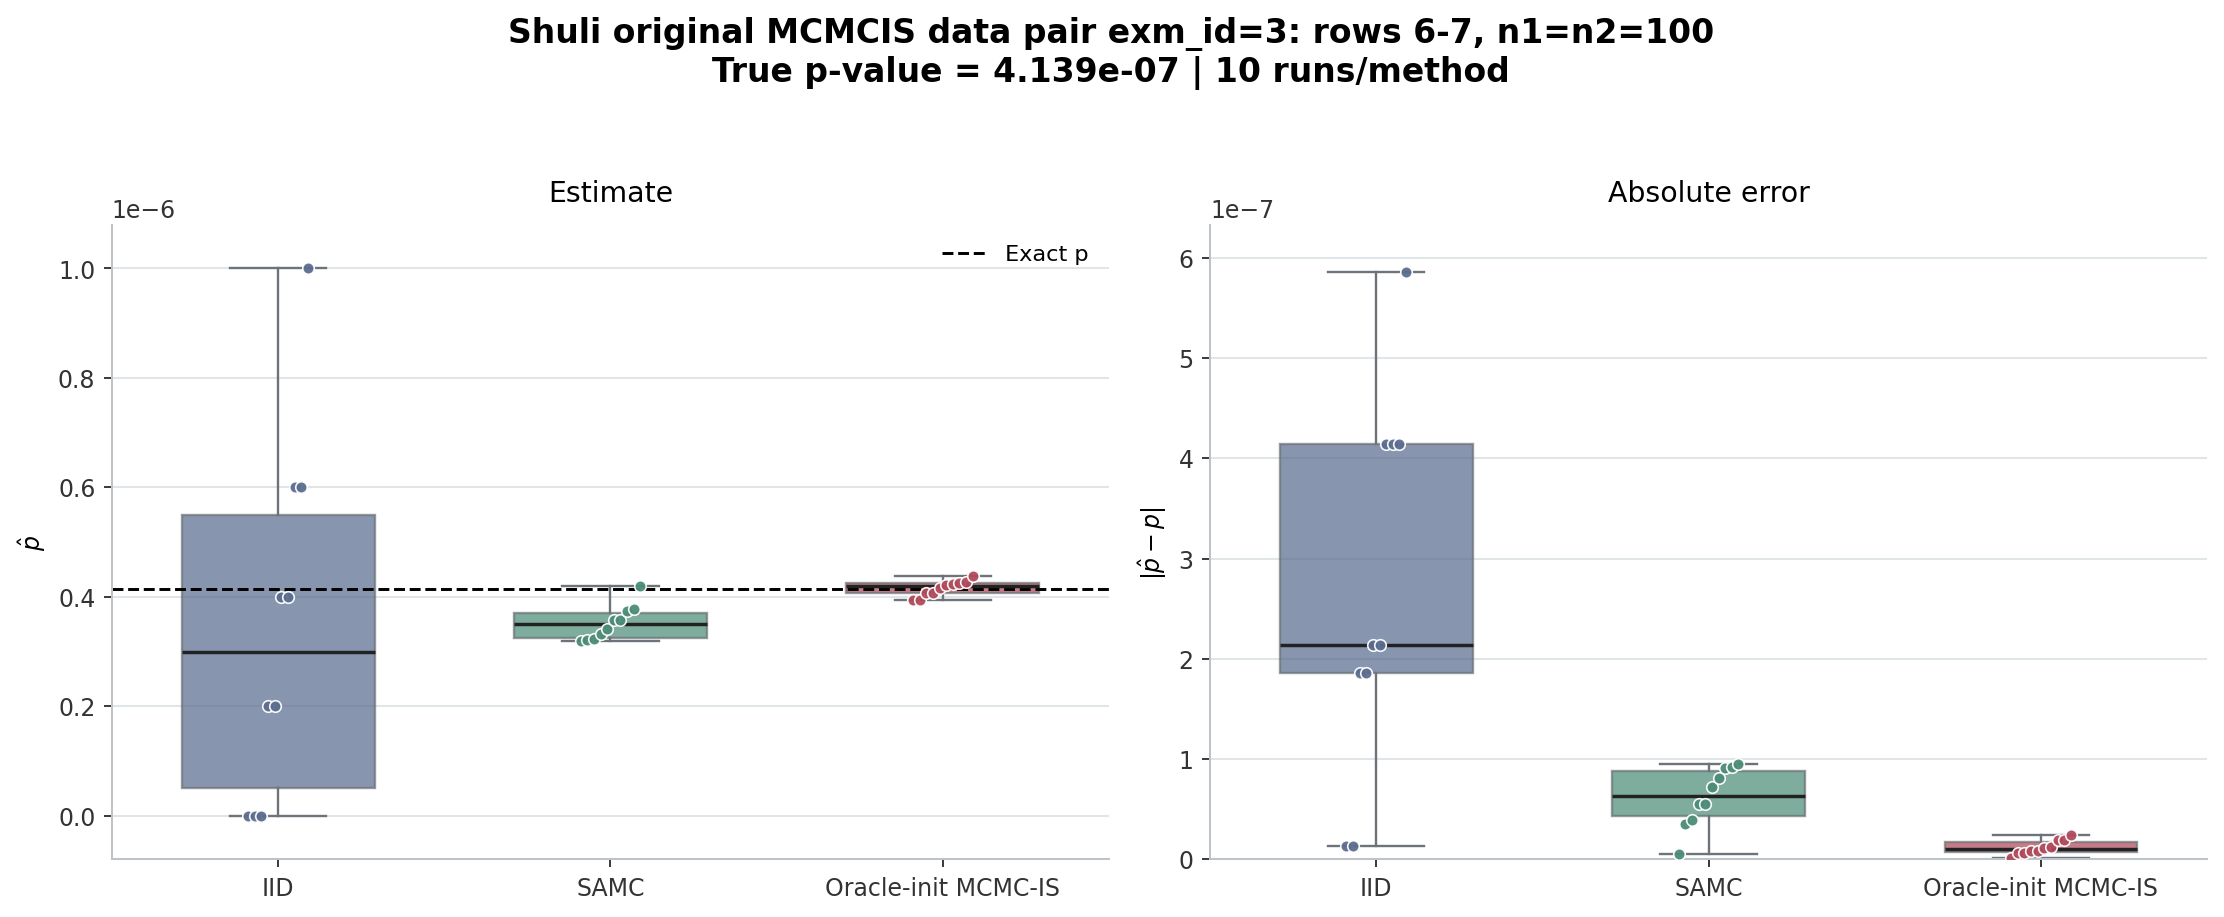

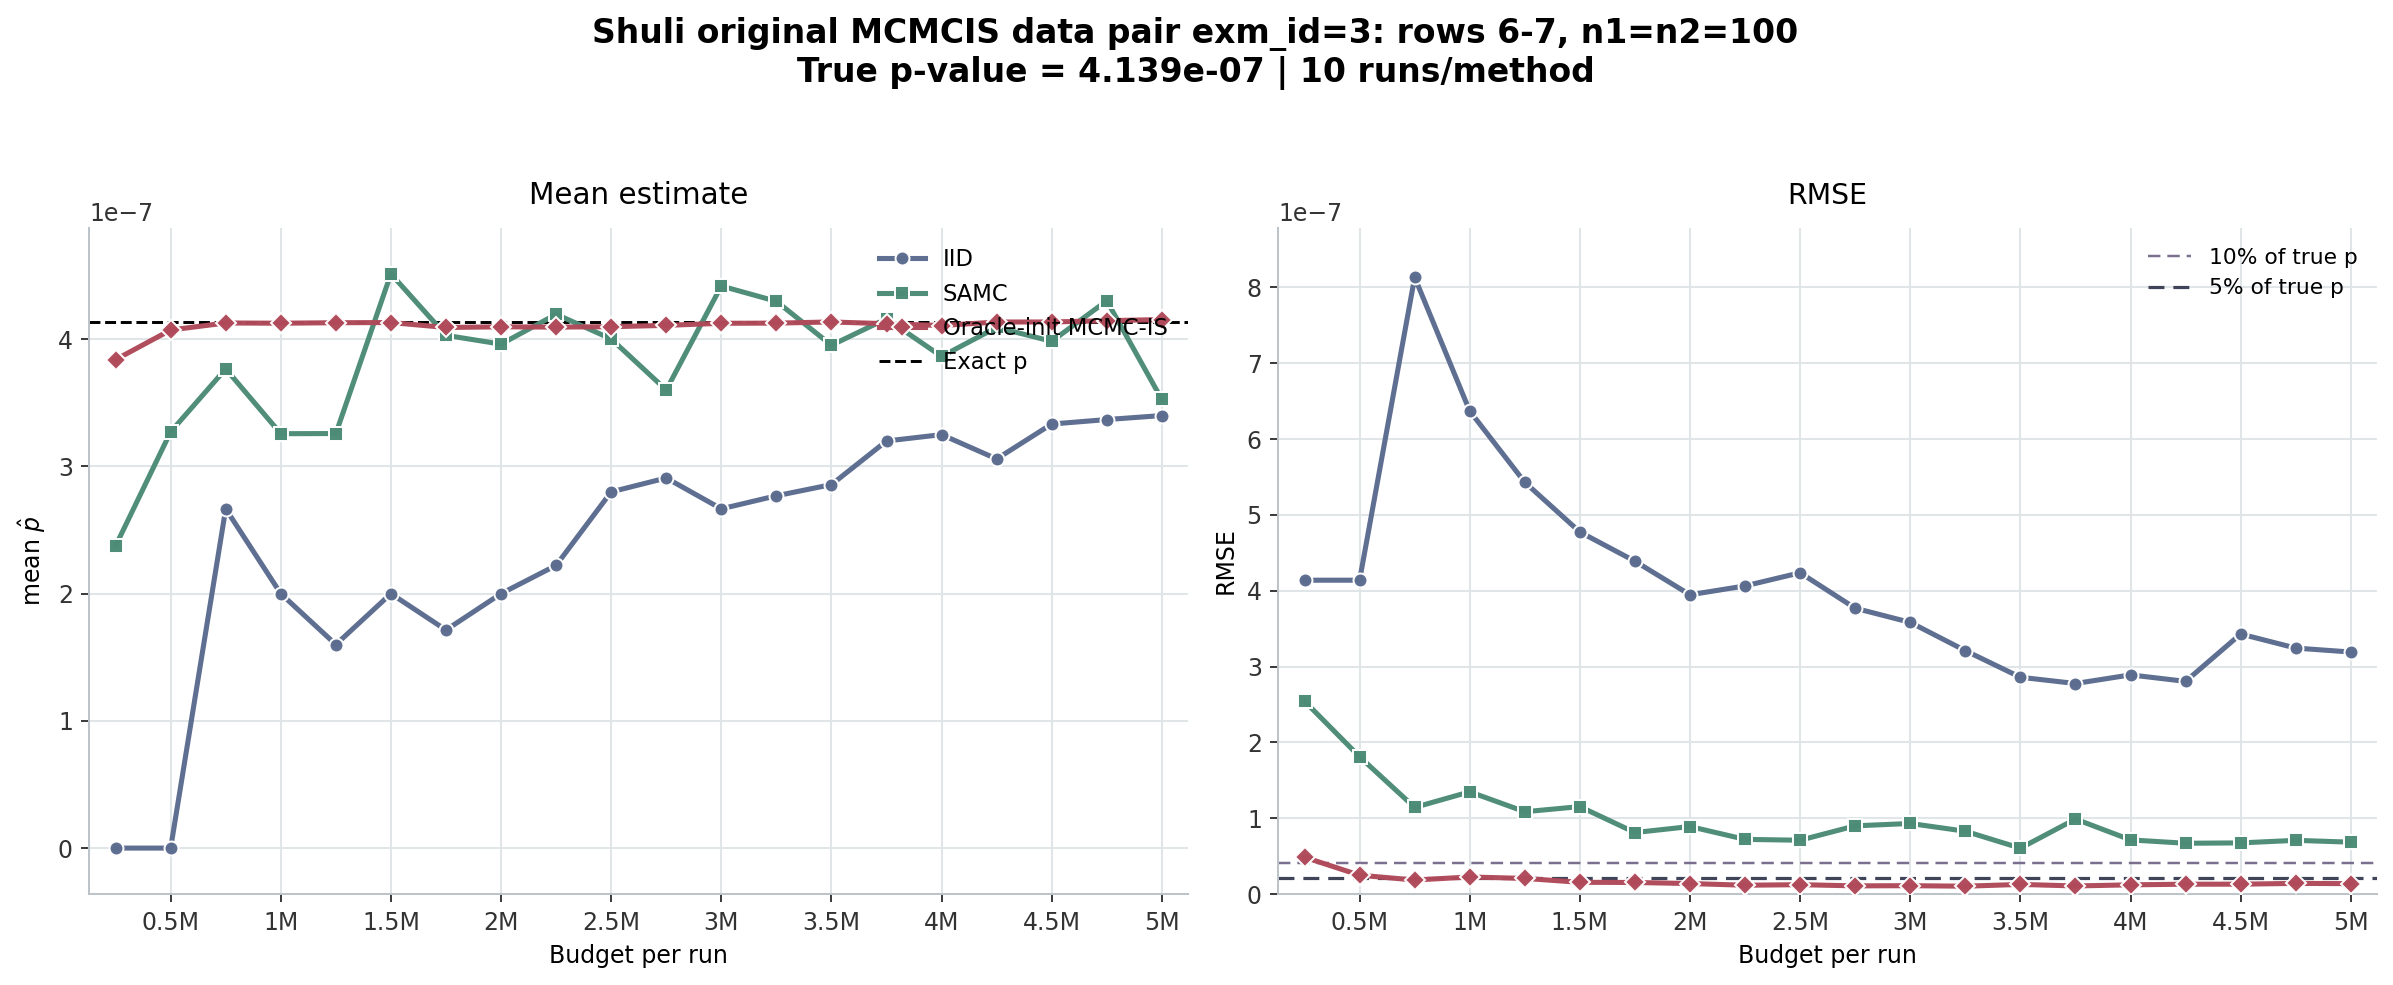

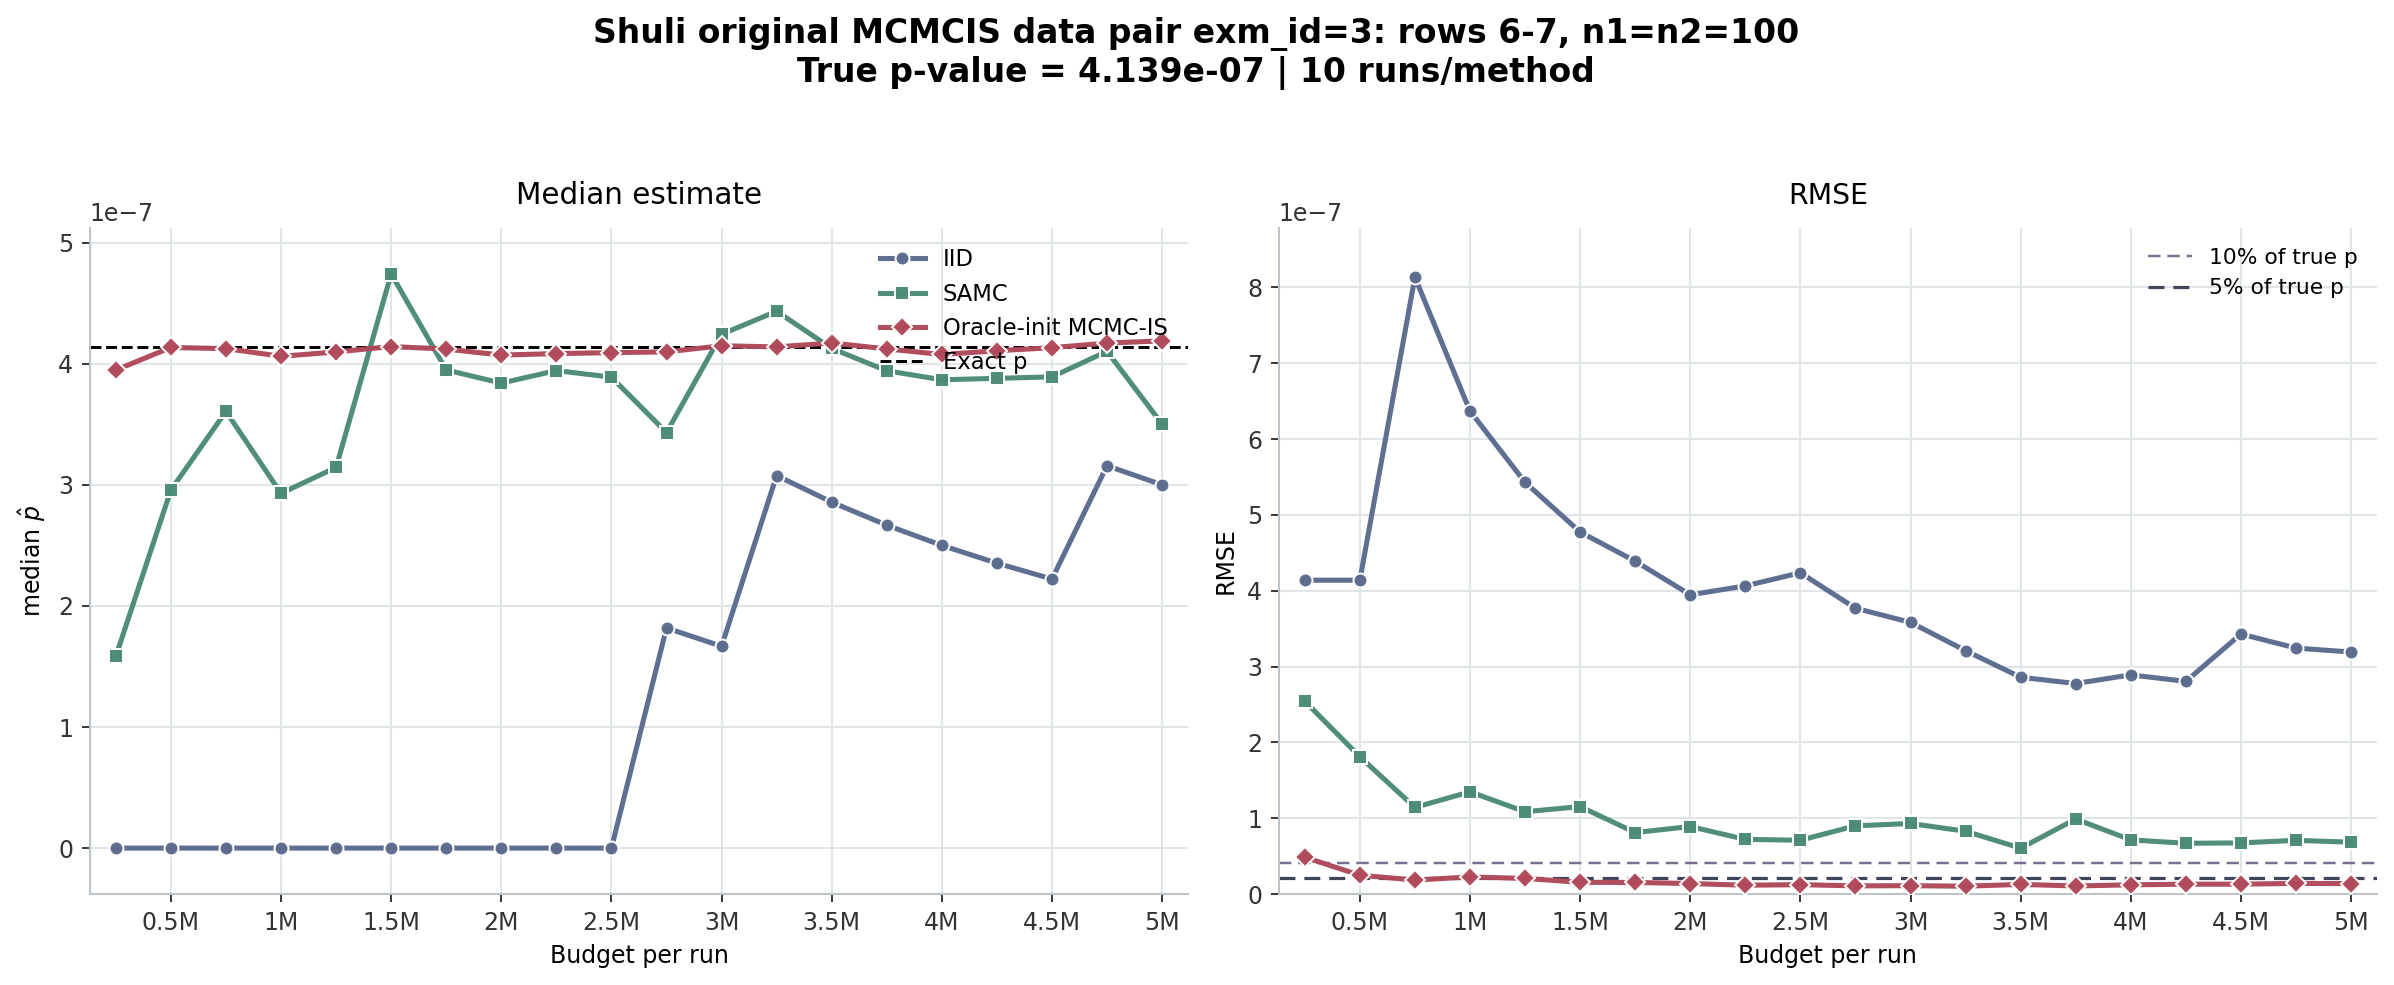

shuli_abs_sumdiff_exm2


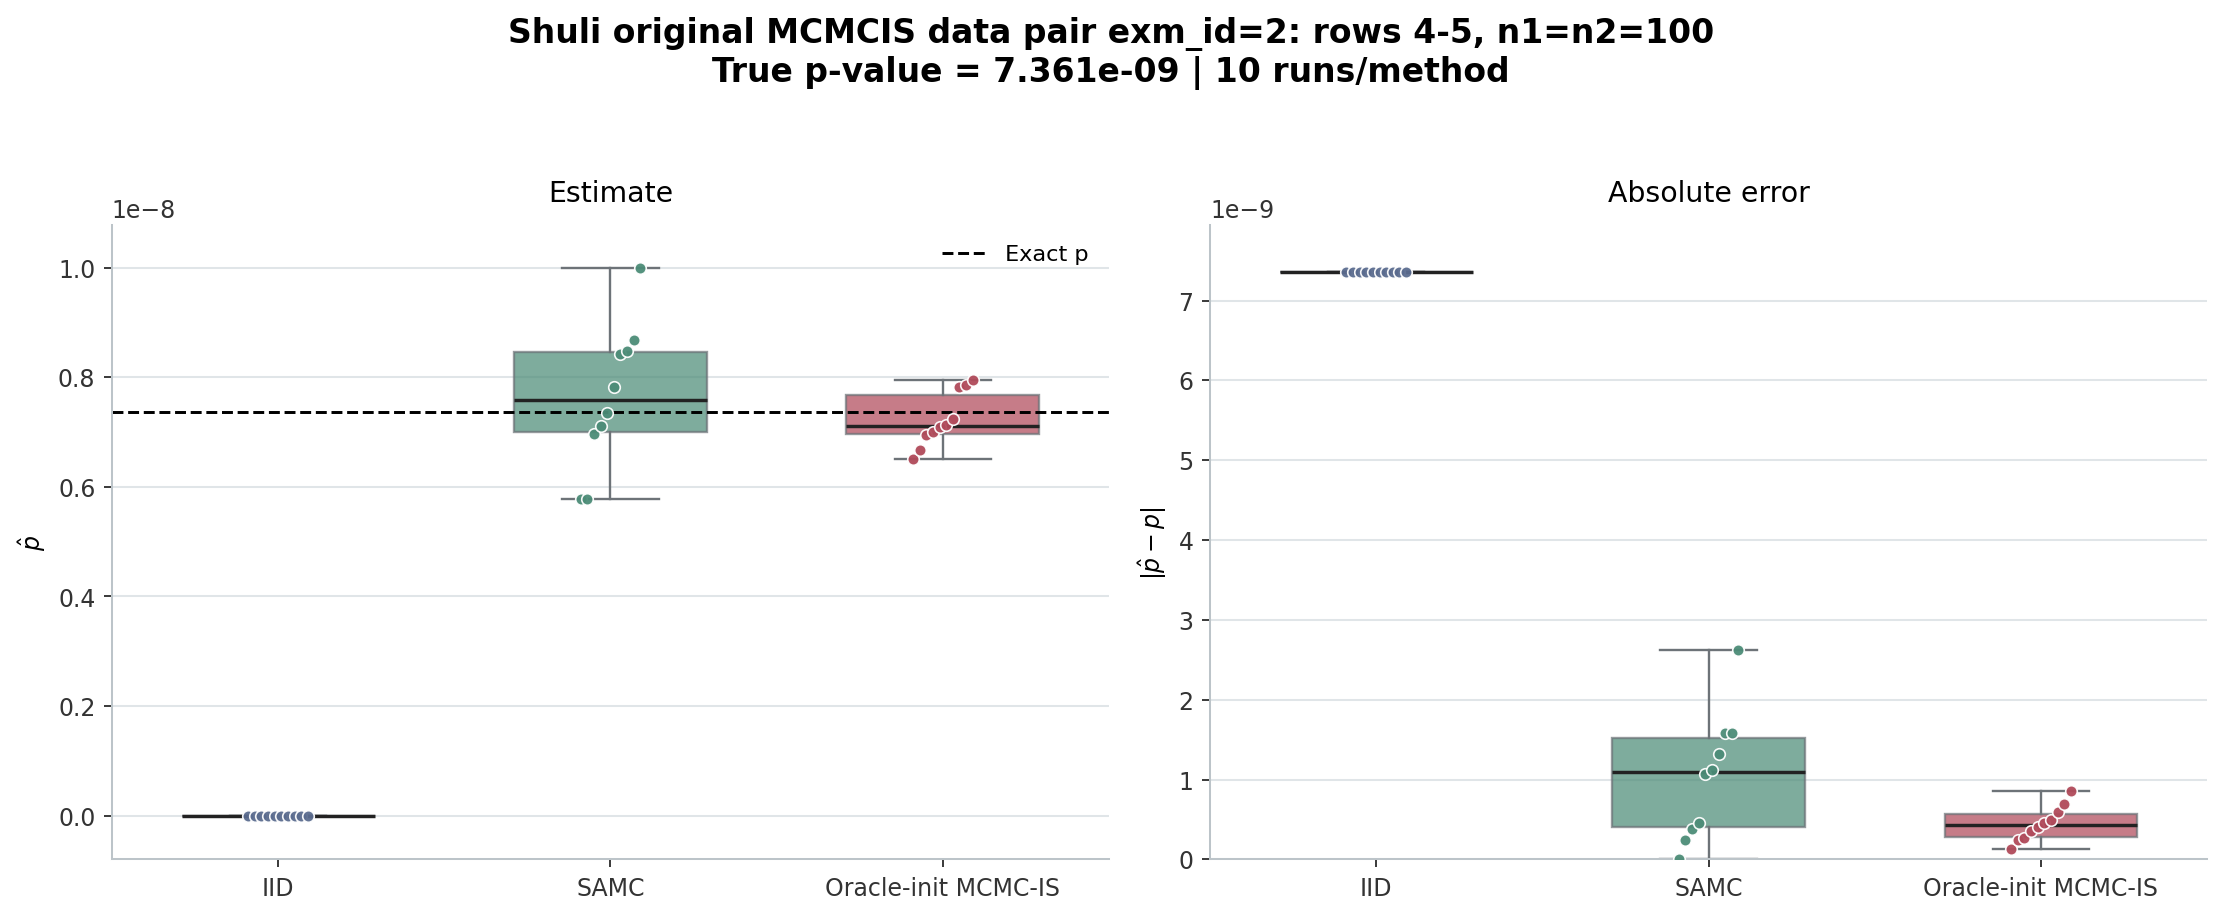

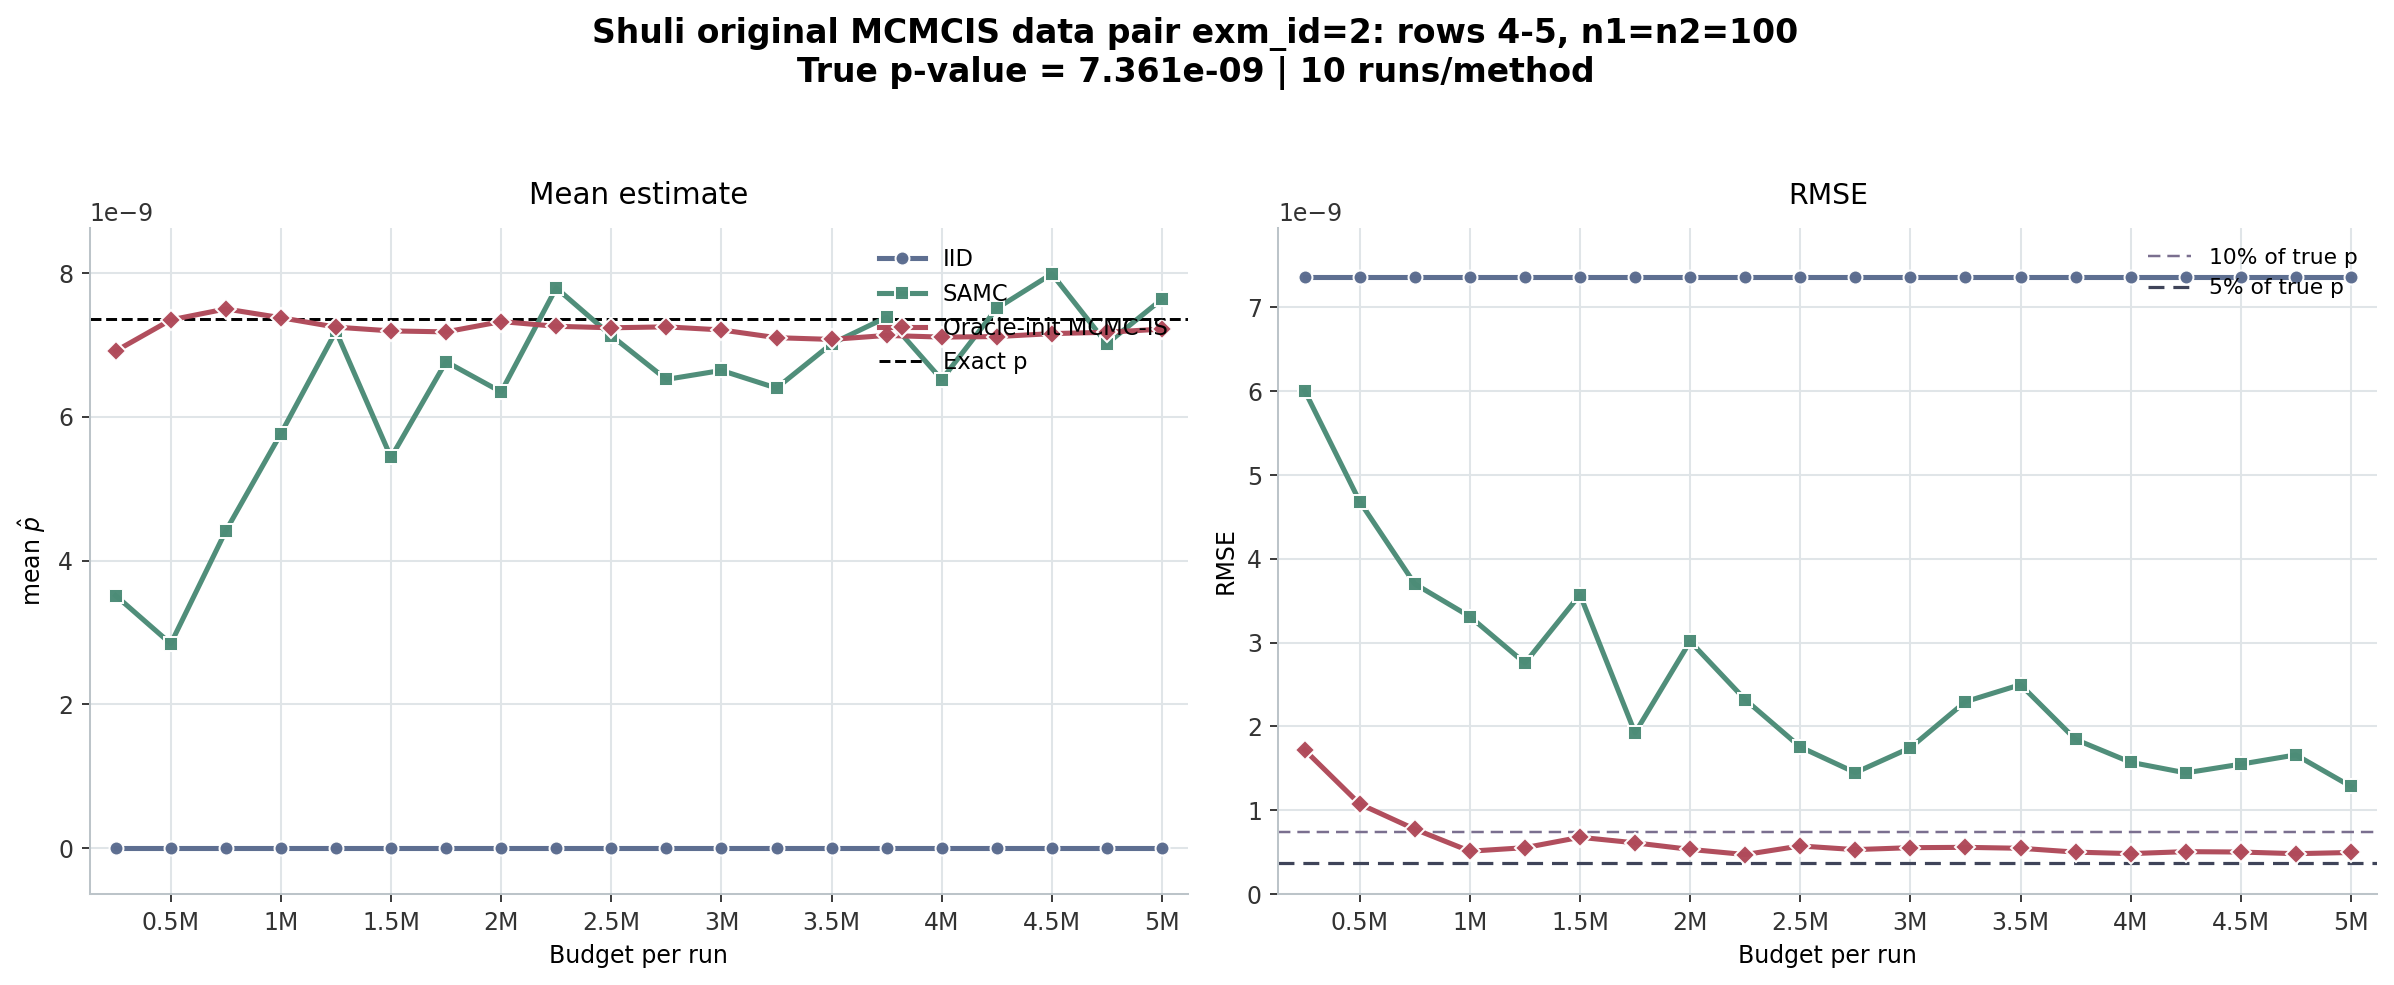

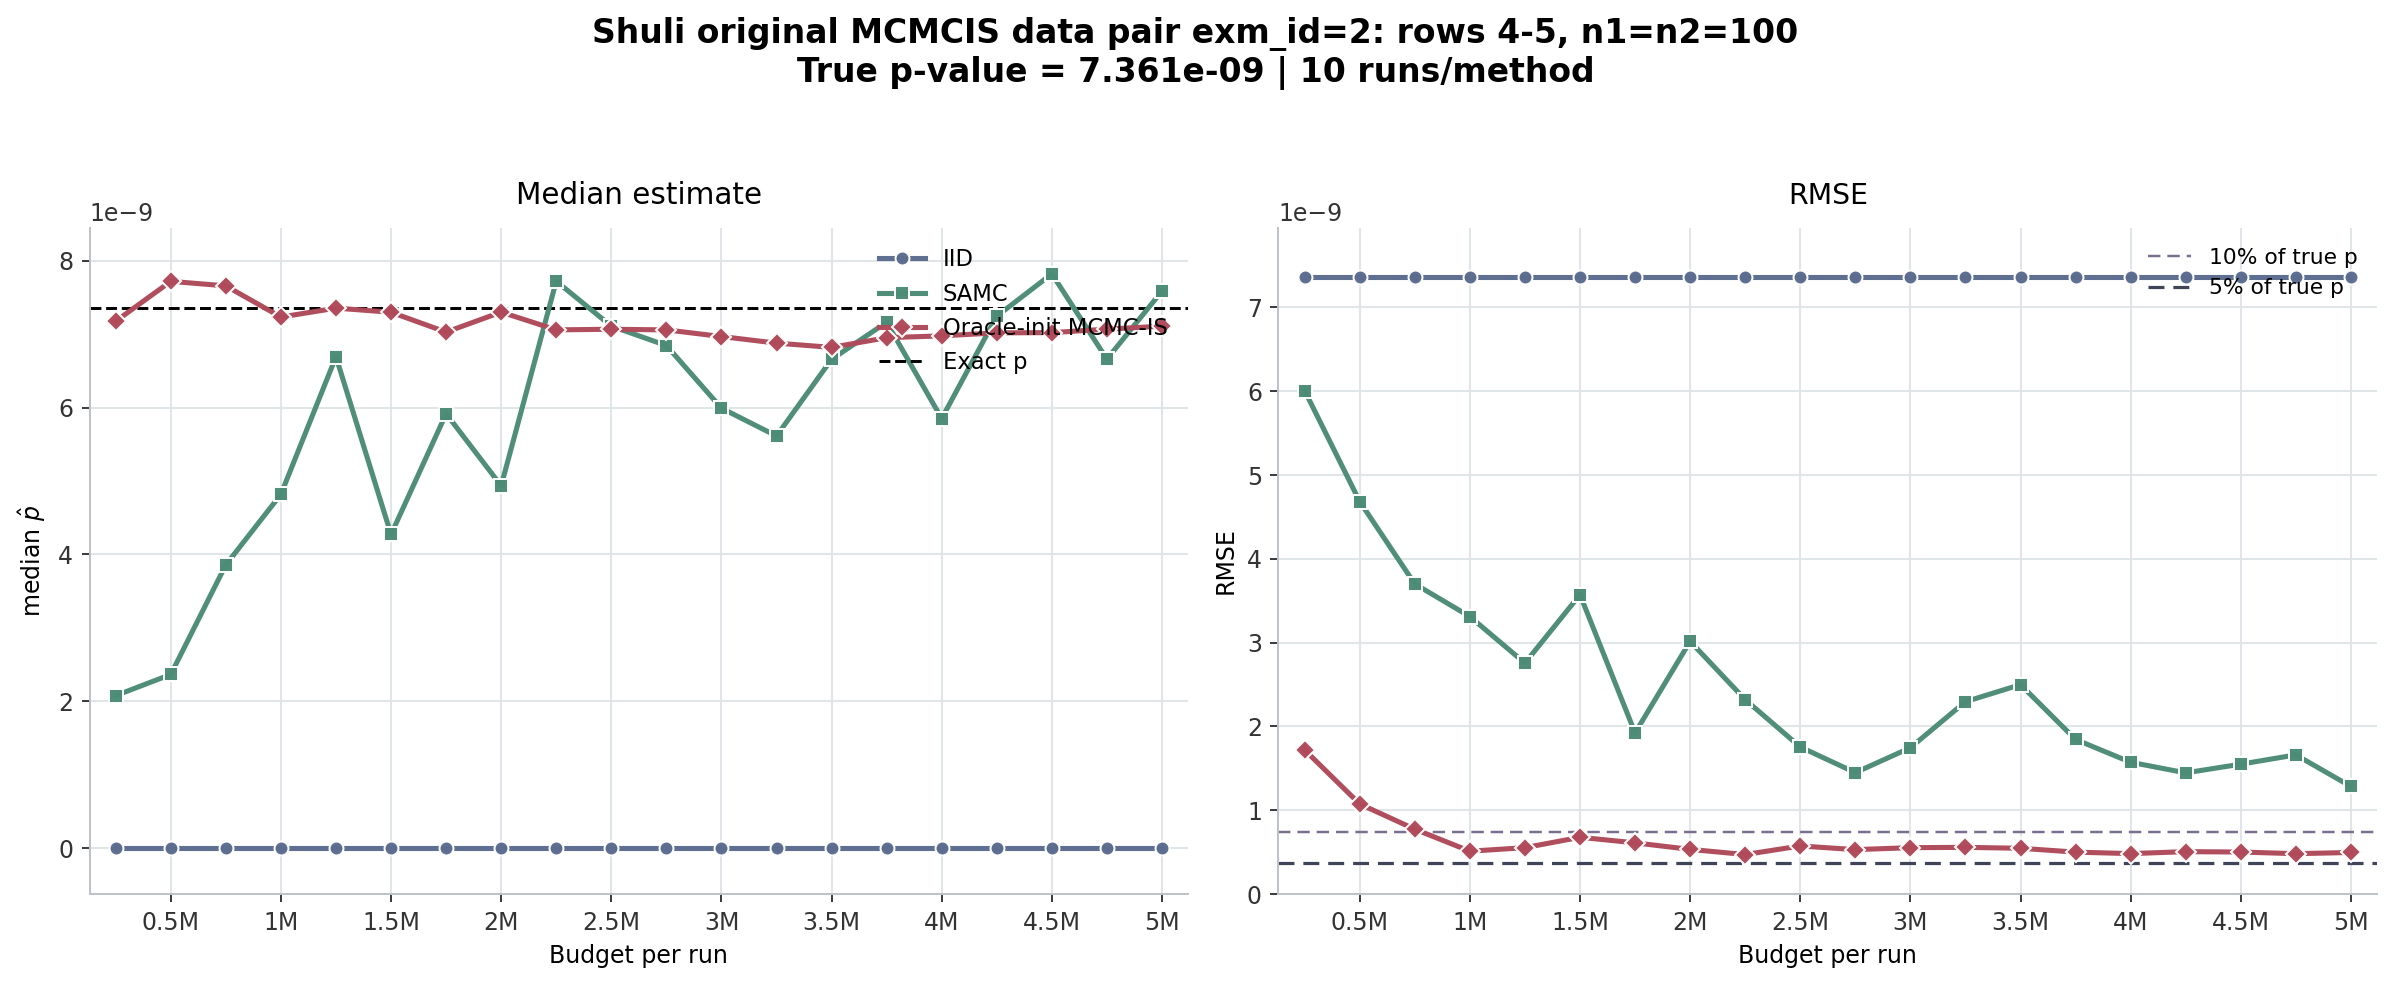

In [7]:
if SAVE_OUTPUTS and run_dir is not None:
    for scenario in scenarios:
        scenario_dir = run_dir / scenario.key
        print(scenario.key)
        for filename in [
            "cross_method_max_budget.png",
            "cross_method_convergence_mean.png",
            "cross_method_convergence_median.png",
        ]:
            path = scenario_dir / filename
            if path.exists():
                display(Image(filename=str(path)))
else:
    print("SAVE_OUTPUTS is False; no figures were written.")


## Reload Saved Results Without Rerunning

Set `RELOAD_SCENARIO_DIR` to a saved scenario directory to inspect prior outputs without launching the expensive run cell.


In [8]:
# RELOAD_SCENARIO_DIR = project_root / "results" / "cross_method_shuli_notebook" / "YYYYMMDD_HHMMSS_shuli_cross_method_oracle_init" / "shuli_abs_sumdiff_exm3"
RELOAD_SCENARIO_DIR = None

if RELOAD_SCENARIO_DIR is not None:
    saved = load_cross_method_saved_output(Path(RELOAD_SCENARIO_DIR))
    display(pd.DataFrame(saved["summary"]).sort_values(["checkpoint", "label"]).tail(12))
    display(pd.DataFrame(saved["records"]).head())
else:
    print("Set RELOAD_SCENARIO_DIR to inspect saved results from disk only.")


Set RELOAD_SCENARIO_DIR to inspect saved results from disk only.
